# African CO₂ Emissions, 1990–2019: Cleaning, Quality Control and Country Profiles

**Goal:** Turn a raw global CO₂ dataset into a clean, documented, analysis-ready African dataset, then answer:
1. How have Africa's emissions changed since 1990?
2. How concentrated are they across countries?
3. How do total and per-capita emissions differ?
4. What does Ghana's trajectory look like compared with its peers?

**Workflow:** source register → data dictionary → standardisation → quality checks → change log → analysis → exports.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, pycountry
from pathlib import Path
pd.set_option("display.width", 140)
RAW = Path("data/raw/Carbon_(CO2)_Emissions_by_Country.csv"); CLEAN = Path("data/clean"); FIG = Path("figures")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": .3})
CHANGELOG = []
def log(step, detail, rows=None): CHANGELOG.append({"step": step, "detail": detail, "rows_affected": rows})

## 1. Source register

In [2]:
source_register = pd.DataFrame([{
    "dataset": "Carbon (CO2) Emissions by Country",
    "file": RAW.name,
    "publisher": "Public Kaggle upload; upstream source not documented in the file",
    "coverage": "190 countries, 1990–2019, annual",
    "variables": "Kilotons of CO2; metric tons per capita",
    "licence_notes": "Treat as secondary data; cross-check against Global Carbon Project / Our World in Data before publication",
    "accessed": "2026-10-01"}])
source_register.T

,0
dataset,Carbon (CO2) Emissions by Country
file,Carbon_(CO2)_Emissions_by_Country.csv
publisher,Public Kaggle upload; upstream source not docu...
coverage,"190 countries, 1990–2019, annual"
variables,Kilotons of CO2; metric tons per capita
licence_notes,Treat as secondary data; cross-check against G...
accessed,2026-10-01


## 2. Load and profile

In [3]:
raw = pd.read_csv(RAW)
print(raw.shape); raw.info()
raw.head()

(5677, 5)
<class 'pandas.DataFrame'>
RangeIndex: 5677 entries, 0 to 5676
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 5677 non-null   str    
 1   Region                  5677 non-null   str    
 2   Date                    5677 non-null   str    
 3   Kilotons of Co2         5677 non-null   float64
 4   Metric Tons Per Capita  5677 non-null   float64
dtypes: float64(2), str(3)
memory usage: 221.9 KB


,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17


In [4]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,5677,190,Afghanistan,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,5677,5,Africa,1585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,5677,30,01-01-2011,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kilotons of Co2,5677.0,NaN,NaN,NaN,141229.164974,649125.822199,0.0,1380.0,9170.0,58480.0,10707219.73
Metric Tons Per Capita,5677.0,NaN,NaN,NaN,4.325505,5.503834,0.0,0.57,2.36,6.34,47.65


## 3. Standardise
Parse dates to years, use snake_case column names, and add ISO3 codes so the data can be joined with World Bank, IEA, and Ember datasets.

In [5]:
df = raw.rename(columns={"Country":"country","Region":"region","Date":"date",
                         "Kilotons of Co2":"co2_kt","Metric Tons Per Capita":"co2_t_per_capita"})
df["year"] = pd.to_datetime(df["date"], format="%d-%m-%Y").dt.year
assert (pd.to_datetime(df["date"], format="%d-%m-%Y").dt.strftime("%d-%m") == "01-01").all()  # every date is 1 Jan → annual data
df = df.drop(columns="date"); log("standardise", "Renamed columns to snake_case; parsed date → year (all dates are 1 January)", len(df))

MANUAL_ISO = {"Democratic Republic Of Congo":"COD","Republic Of Congo":"COG","Cabo Verde":"CPV",
              "Sao Tome And Principe":"STP","Eswatini":"SWZ","Tanzania":"TZA","Libya":"LBY","Lao PDR":"LAO","St. Kitts And Nevis":"KNA","St. Lucia":"LCA","St. Vincent And The Grenadines":"VCT","Turkey":"TUR"}
def to_iso3(name):
    if name in MANUAL_ISO: return MANUAL_ISO[name]
    try: return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        try: return pycountry.countries.search_fuzzy(name)[0].alpha_3
        except LookupError: return None
iso = {c: to_iso3(c) for c in df["country"].unique()}
df["iso3"] = df["country"].map(iso)
unmatched = sorted(c for c, v in iso.items() if v is None)
log("standardise", f"Added ISO3 codes ({len(MANUAL_ISO)} manual overrides); unmatched: {unmatched}", int(df['iso3'].isna().sum()))
print("Unmatched countries:", unmatched)

Unmatched countries: []


In [6]:
af = df[df["region"] == "Africa"].copy()
print(af["country"].nunique(), "African countries,", len(af), "rows")

53 African countries, 1585 rows


## 4. Quality checks
Each check writes flags to a QC table instead of silently dropping rows.

In [7]:
qc = []
def flag(rows, check, severity, note):
    for _, r in rows.iterrows(): qc.append({"country": r["country"], "year": r.get("year"), "check": check, "severity": severity, "note": note})

# 4a. Coverage: which AU/UN African states are absent?
AFRICA_UN = {c.alpha_3 for c in pycountry.countries} & {
 "DZA","AGO","BEN","BWA","BFA","BDI","CPV","CMR","CAF","TCD","COM","COD","COG","CIV","DJI","EGY","GNQ","ERI","SWZ","ETH",
 "GAB","GMB","GHA","GIN","GNB","KEN","LSO","LBR","LBY","MDG","MWI","MLI","MRT","MUS","MAR","MOZ","NAM","NER","NGA","RWA",
 "STP","SEN","SYC","SLE","SOM","ZAF","SSD","SDN","TZA","TGO","TUN","UGA","ZMB","ZWE"}
missing_countries = sorted(AFRICA_UN - set(af["iso3"]))
for m in missing_countries:
    qc.append({"country": pycountry.countries.get(alpha_3=m).name, "year": None, "check": "coverage", "severity": "high",
               "note": "Country absent from the source; regional totals are understated"})
print("Missing African UN members:", missing_countries)

# 4b. Year gaps
full = set(range(1990, 2020))
for c, g in af.groupby("country"):
    gaps = sorted(full - set(g["year"]))
    if gaps: qc.append({"country": c, "year": None, "check": "year_gap", "severity": "medium", "note": f"Missing years: {gaps}"})

# 4c. Duplicates
dups = af[af.duplicated(["country","year"], keep=False)]; flag(dups, "duplicate", "high", "Duplicate country-year")

# 4d. Zeros / implausible values
flag(af[af["co2_kt"] == 0], "zero_value", "high", "Zero total emissions is implausible for a national economy")
flag(af[(af["co2_t_per_capita"] == 0) & (af["co2_kt"] > 0)], "unit_inconsistency", "high",
     "Per-capita = 0 while total > 0 (rounding to 2 dp hides small values, or the source is wrong)")

# 4e. Year-on-year jumps > 100 %
t = af.sort_values(["country","year"]).copy()
t["yoy"] = t.groupby("country")["co2_kt"].pct_change()
flag(t[t["yoy"].abs() > 1.0], "yoy_jump", "medium", "Year-on-year change > ±100 %: check for a structural break or a data error")

# 4f. Internal consistency: implied population = kt*1000 / t-per-capita should move smoothly
t["implied_pop_m"] = t["co2_kt"] * 1000 / t["co2_t_per_capita"].replace(0, np.nan) / 1e6
t["pop_yoy"] = t.groupby("country")["implied_pop_m"].pct_change()
flag(t[(t["pop_yoy"].abs() > 0.25) & (t["co2_t_per_capita"] >= 0.1)], "implied_population", "low",
     "Implied population moves > 25 % in a year: the total and per-capita columns disagree")

qc = pd.DataFrame(qc)
qc.groupby(["check","severity"]).size().rename("flags").reset_index()

Missing African UN members: ['CIV']


,check,severity,flags
0,coverage,high,1
1,unit_inconsistency,high,7
2,year_gap,medium,3
3,yoy_jump,medium,5
4,zero_value,high,1


In [8]:
qc[qc["severity"] == "high"]

,country,year,check,severity,note
0,Côte d'Ivoire,NaN,coverage,high,Country absent from the source; regional total...
4,Mali,1996.0,zero_value,high,Zero total emissions is implausible for a nati...
5,Mali,1990.0,unit_inconsistency,high,Per-capita = 0 while total > 0 (rounding to 2 ...
6,Mali,1991.0,unit_inconsistency,high,Per-capita = 0 while total > 0 (rounding to 2 ...
7,Mali,1992.0,unit_inconsistency,high,Per-capita = 0 while total > 0 (rounding to 2 ...
8,Mali,1993.0,unit_inconsistency,high,Per-capita = 0 while total > 0 (rounding to 2 ...
9,Mali,1994.0,unit_inconsistency,high,Per-capita = 0 while total > 0 (rounding to 2 ...
10,Mali,1995.0,unit_inconsistency,high,Per-capita = 0 while total > 0 (rounding to 2 ...
11,Mali,1997.0,unit_inconsistency,high,Per-capita = 0 while total > 0 (rounding to 2 ...


In [9]:
qc[qc["check"].isin(["yoy_jump","year_gap"])].sort_values("country")

,country,year,check,severity,note
12,Benin,1996.0,yoy_jump,medium,Year-on-year change > ±100 %: check for a stru...
13,Cameroon,1991.0,yoy_jump,medium,Year-on-year change > ±100 %: check for a stru...
14,Equatorial Guinea,1992.0,yoy_jump,medium,Year-on-year change > ±100 %: check for a stru...
1,Eritrea,NaN,year_gap,medium,"Missing years: [1990, 1991]"
2,Mali,NaN,year_gap,medium,"Missing years: [1998, 1999]"
15,Mali,1997.0,yoy_jump,medium,Year-on-year change > ±100 %: check for a stru...
16,Mali,2000.0,yoy_jump,medium,Year-on-year change > ±100 %: check for a stru...
3,Namibia,NaN,year_gap,medium,Missing years: [1990]


### QC decisions
| Issue | Decision | Why |
|---|---|---|
| Côte d'Ivoire missing | Keep the gap and report it | Imputing a whole country would invent data. Totals are labelled "53 countries". |
| Mali 1990–1997 (10 kt, 0 t/capita; one year at 0 kt) | Set to missing | Values are ~140× below Mali's later level, so they are almost certainly placeholders |
| Year gaps (Eritrea, Namibia, Mali) | Keep as missing; no interpolation | Eritrea (independent 1993) and Namibia (1990) gaps match statehood dates |
| Large jumps (Equatorial Guinea 1992, Benin 1996, Cameroon 1991) | Keep, flagged | Equatorial Guinea plausibly reflects early oil and gas development. All three need checking against the upstream source. |

In [10]:
bad = (af["country"] == "Mali") & (af["year"] <= 1997)
af.loc[bad, ["co2_kt","co2_t_per_capita"]] = np.nan
log("clean", "Mali 1990–1997 set to NaN (implausible placeholder values)", int(bad.sum()))
af["qc_flag"] = af.set_index(["country","year"]).index.isin(qc.dropna(subset=["year"]).set_index(["country","year"]).index)
log("clean", "Added qc_flag column (True if the row has any QC flag)", int(af["qc_flag"].sum()))
af = af[["iso3","country","region","year","co2_kt","co2_t_per_capita","qc_flag"]].sort_values(["country","year"]).reset_index(drop=True)
af.head()

,iso3,country,region,year,co2_kt,co2_t_per_capita,qc_flag
0,DZA,Algeria,Africa,1990,62940.0,2.47,False
1,DZA,Algeria,Africa,1991,66430.0,2.54,False
2,DZA,Algeria,Africa,1992,66840.0,2.50,False
3,DZA,Algeria,Africa,1993,72220.0,2.64,False
4,DZA,Algeria,Africa,1994,73610.0,2.63,False


## 5. Analysis

### 5.1 Africa's total emissions over time

Africa (53 countries): 613 Mt (1990) → 1,392 Mt (2019); x2.27, CAGR 2.9%


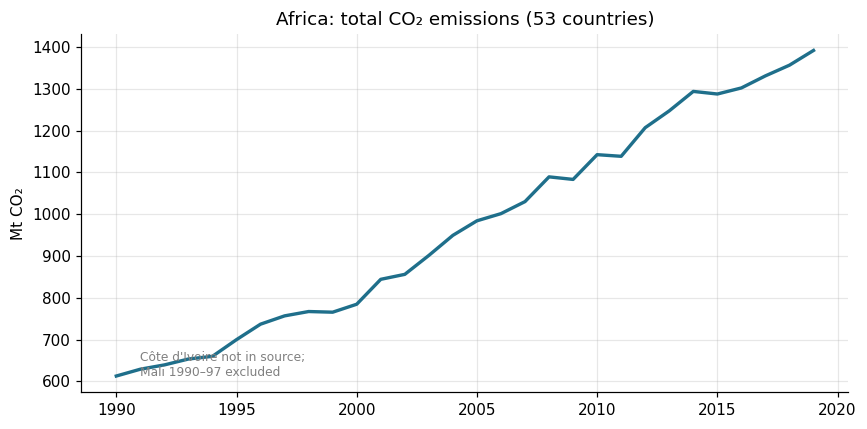

In [11]:
tot = af.groupby("year")["co2_kt"].sum() / 1000  # Mt
cagr = (tot.loc[2019] / tot.loc[1990]) ** (1/29) - 1
print(f"Africa (53 countries): {tot.loc[1990]:,.0f} Mt (1990) → {tot.loc[2019]:,.0f} Mt (2019); x{tot.loc[2019]/tot.loc[1990]:.2f}, CAGR {cagr:.1%}")
fig, ax = plt.subplots(figsize=(8,4))
tot.plot(ax=ax, color="#1f6f8b", lw=2.2)
ax.set(title="Africa: total CO₂ emissions (53 countries)", ylabel="Mt CO₂", xlabel="")
ax.annotate("Côte d'Ivoire not in source;\nMali 1990–97 excluded", xy=(1991, tot.min()), fontsize=8, color="grey")
plt.tight_layout(); plt.savefig(FIG/"africa_total.png"); plt.show()

### 5.2 Concentration: the top emitters dominate

Top 3 share of 2019 emissions: 62%; top 10: 86%


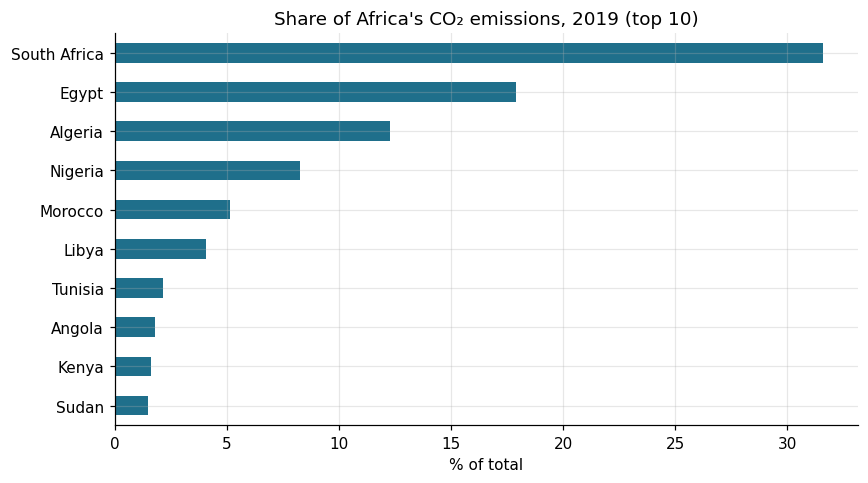

In [12]:
y19 = af[af["year"] == 2019].sort_values("co2_kt", ascending=False)
share = y19.set_index("country")["co2_kt"] / y19["co2_kt"].sum()
print(f"Top 3 share of 2019 emissions: {share.head(3).sum():.0%}; top 10: {share.head(10).sum():.0%}")
fig, ax = plt.subplots(figsize=(8,4.5))
(share.head(10)[::-1]*100).plot.barh(ax=ax, color=["#e07a5f" if c=="Ghana" else "#1f6f8b" for c in share.head(10).index[::-1]])
ax.set(title="Share of Africa's CO₂ emissions, 2019 (top 10)", xlabel="% of total", ylabel="")
plt.tight_layout(); plt.savefig(FIG/"top10_share_2019.png"); plt.show()

### 5.3 Total and per-capita emissions tell different stories

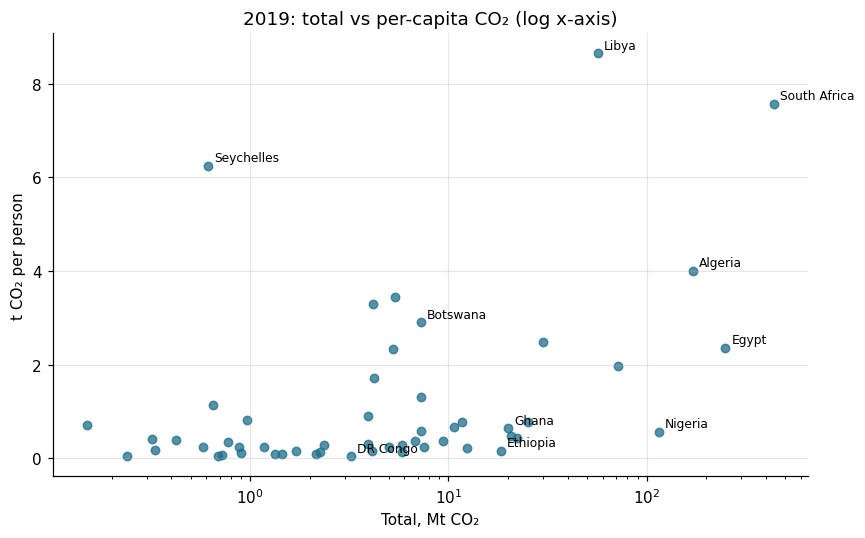

,country,co2_kt,co2_t_per_capita
807,Libya,56800.00,8.65
1344,South Africa,439640.01,7.57
1254,Seychelles,610.00,6.25
29,Algeria,171250.00,4.01
449,Equatorial Guinea,5350.00,3.44
955,Mauritius,4170.00,3.29
119,Botswana,7250.00,2.90
1494,Tunisia,29910.00,2.48


In [13]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(y19["co2_kt"]/1000, y19["co2_t_per_capita"], s=30, color="#1f6f8b", alpha=.75)
for _, r in y19.iterrows():
    if r["country"] in ["South Africa","Egypt","Algeria","Nigeria","Libya","Seychelles","Ghana","Ethiopia","Botswana","DR Congo","Democratic Republic Of Congo"]:
        ax.annotate(r["country"].replace("Democratic Republic Of Congo","DR Congo"), (r["co2_kt"]/1000, r["co2_t_per_capita"]), fontsize=8, xytext=(4,3), textcoords="offset points")
ax.set_xscale("log"); ax.set(title="2019: total vs per-capita CO₂ (log x-axis)", xlabel="Total, Mt CO₂", ylabel="t CO₂ per person")
plt.tight_layout(); plt.savefig(FIG/"total_vs_per_capita_2019.png"); plt.show()
y19[["country","co2_kt","co2_t_per_capita"]].sort_values("co2_t_per_capita", ascending=False).head(8)

### 5.4 Fastest growth, 2000–2019 (CAGR)
The window starts in 2000 so that the Mali exclusion and the early-1990s breaks don't distort the results. Small emitters below 1 Mt in 2000 are left out because tiny bases give extreme growth rates.

In [14]:
p = af.pivot(index="country", columns="year", values="co2_kt")
g = ((p[2019] / p[2000]) ** (1/19) - 1).where(p[2000] >= 1000).dropna().sort_values(ascending=False)
print("Median CAGR:", f"{g.median():.1%}"); print("Ghana rank:", list(g.index).index("Ghana")+1, "of", len(g))
(g.head(10)*100).round(1).rename("CAGR % 2000–2019").to_frame()

Median CAGR: 4.2%
Ghana rank: 9 of 32


,CAGR % 2000–2019
country,
Mozambique,9.1
Ethiopia,9.0
Benin,9.0
Uganda,8.2
Tanzania,7.9
Mali,7.8
Zambia,7.2
Sudan,7.0
Ghana,6.8


### 5.5 Country profile: Ghana

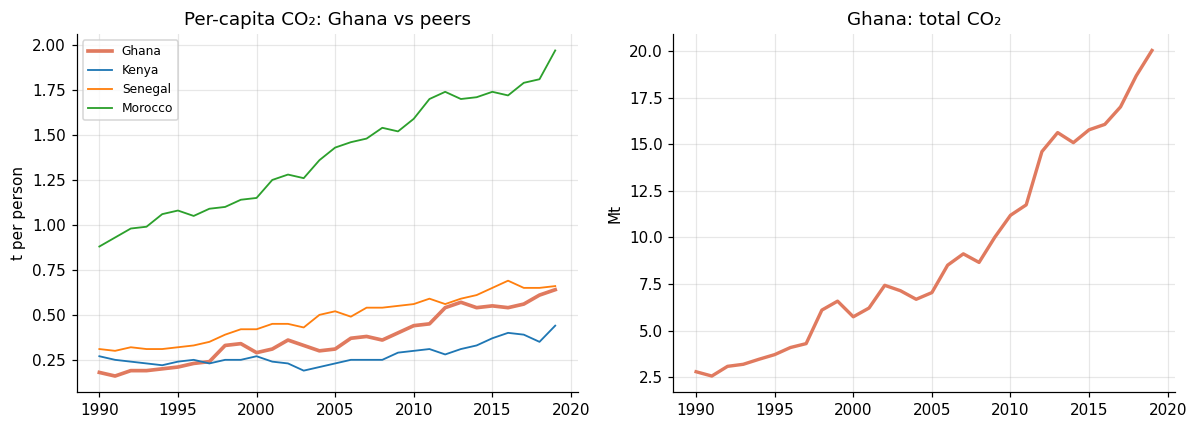

Ghana: 2.8 Mt → 20.0 Mt (x7.2); per capita 0.18 → 0.64 t


In [15]:
gh = af[af["country"] == "Ghana"].set_index("year")
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for c in ["Ghana","Kenya","Senegal","Morocco"]:
    s = af[af["country"]==c].set_index("year")["co2_t_per_capita"]
    axes[0].plot(s.index, s, lw=2.4 if c=="Ghana" else 1.2, color="#e07a5f" if c=="Ghana" else None, label=c)
axes[0].set(title="Per-capita CO₂: Ghana vs peers", ylabel="t per person"); axes[0].legend(fontsize=8)
(gh["co2_kt"]/1000).plot(ax=axes[1], color="#e07a5f", lw=2.2); axes[1].set(title="Ghana: total CO₂", ylabel="Mt", xlabel="")
plt.tight_layout(); plt.savefig(FIG/"ghana_profile.png"); plt.show()
print(f"Ghana: {gh.loc[1990,'co2_kt']/1000:.1f} Mt → {gh.loc[2019,'co2_kt']/1000:.1f} Mt (x{gh.loc[2019,'co2_kt']/gh.loc[1990,'co2_kt']:.1f}); "
      f"per capita {gh.loc[1990,'co2_t_per_capita']} → {gh.loc[2019,'co2_t_per_capita']} t")

## 6. Exports: clean data, data dictionary, QC log, change log

In [16]:
dictionary = pd.DataFrame([
 ("iso3","str","ISO 3166-1 alpha-3 code","Derived (pycountry + manual overrides)"),
 ("country","str","Country name as given in the source","Source"),
 ("region","str","Continent grouping (always 'Africa' here)","Source"),
 ("year","int","Calendar year","Derived from the source date (1 January)"),
 ("co2_kt","float","Total CO₂ emissions, kilotonnes","Source; Mali 1990–97 set to NaN"),
 ("co2_t_per_capita","float","CO₂ per person, tonnes (rounded to 2 dp in the source)","Source; Mali 1990–97 set to NaN"),
 ("qc_flag","bool","True if the row has any entry in qc_log.csv","Derived")],
 columns=["column","dtype","definition","provenance"])
af.to_csv(CLEAN/"africa_co2_clean.csv", index=False)
dictionary.to_csv(CLEAN/"data_dictionary.csv", index=False)
qc.to_csv(CLEAN/"qc_log.csv", index=False)
source_register.to_csv(CLEAN/"source_register.csv", index=False)
pd.DataFrame(CHANGELOG).to_csv(CLEAN/"change_log.csv", index=False)
pd.DataFrame(CHANGELOG)

,step,detail,rows_affected
0,standardise,Renamed columns to snake_case; parsed date → y...,5677
1,standardise,Added ISO3 codes (12 manual overrides); unmatc...,0
2,clean,Mali 1990–1997 set to NaN (implausible placeho...,8
3,clean,Added qc_flag column (True if the row has any ...,12


## 7. Findings
- **Growth:** emissions in the 53 countries rose from 613 Mt to 1,392 Mt (×2.3; CAGR 2.9 %) between 1990 and 2019.
- **Concentration:** 62 % of 2019 emissions come from just three countries (South Africa, Egypt, Algeria), and 86 % from the top 10. Policy focus and data quality for these three matter most.
- **Total ≠ per capita:** Nigeria is the 4th-largest emitter in total, but its per-capita level is low (0.57 t). Small, rich or oil-producing states such as Seychelles and Libya have the highest per-capita levels.
- **Ghana:** total emissions grew about 7× from 1990 to 2019 (2.8 → 20.0 Mt), and per-capita emissions grew from 0.18 to 0.64 t. Ghana's 2000–2019 growth ranks 9th of 32 countries (median CAGR 4.2 %), but its per-capita level is still low.

## 8. Limitations and next steps
- The upstream source is undocumented, and Côte d'Ivoire is missing. **Next step:** reconcile with Global Carbon Project / OWID by ISO3 and quantify the differences.
- There is no sector split (power, transport, industry). **Next step:** join with Ember electricity data to separate power-sector emissions.
- Per-capita values are rounded to 2 dp, which limits the precision of the consistency checks for low emitters.